## White Wine Quality Prediction

Given *data about various white wines*, let's try to predict the **quality** of a particular wine, according to experts.

We will use a TensorFlow ANN to make our predictions.

Data source: https://www.kaggle.com/datasets/piyushagni5/white-wine-quality

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [2]:
data = pd.read_csv('archive/winequality-white.csv', delimiter=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


### Visualization

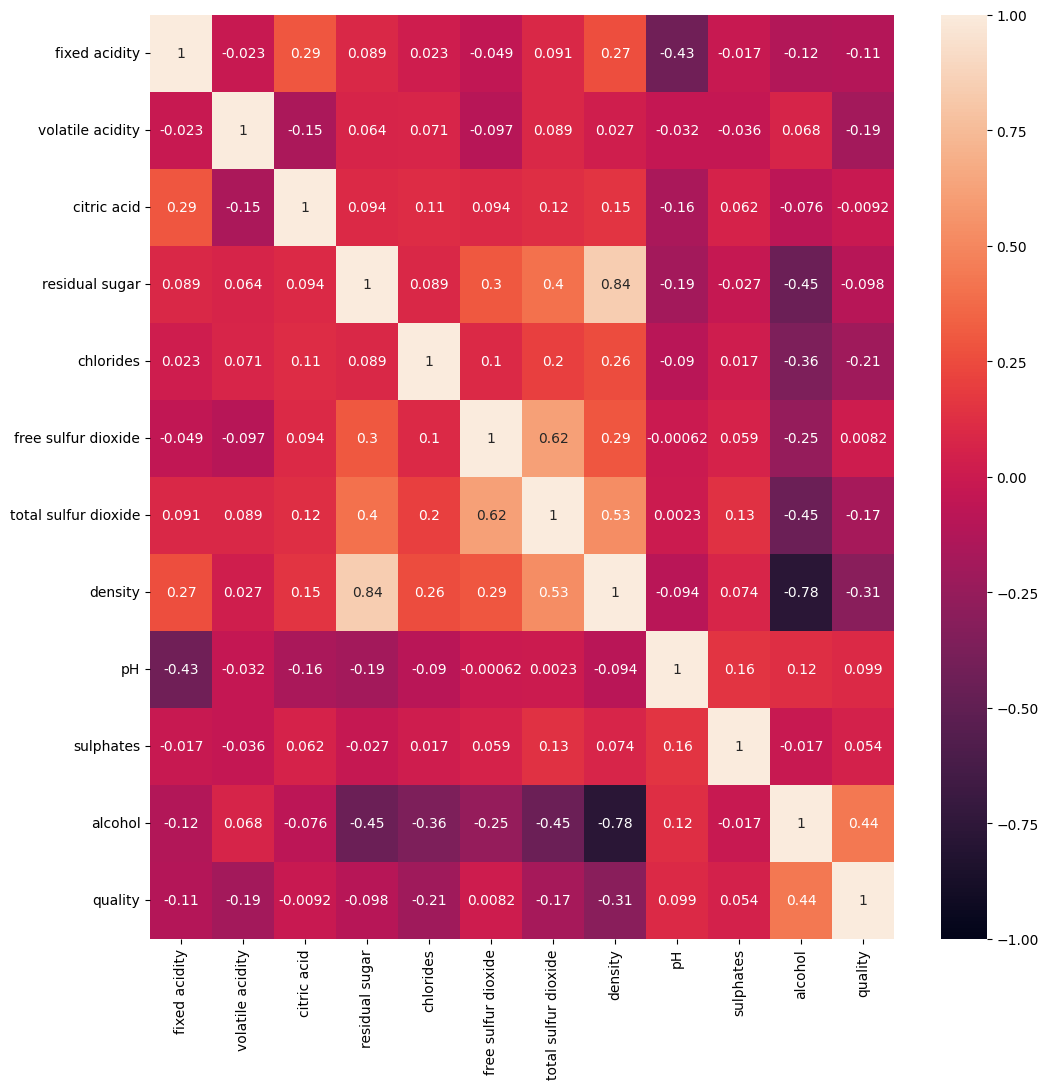

In [4]:
corr = data.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, vmin=-1.0, vmax=1.0)
plt.show()

### Preprocessing

In [5]:
df = data.copy()

In [6]:
print("Total Null Values:", df.isna().sum().sum())

Total Null Values: 0


In [7]:
df['quality'].unique()

array([6, 5, 7, 8, 4, 3, 9])

In [8]:
encoder = LabelEncoder()

df['quality'] = encoder.fit_transform(df['quality'])

{index:label for index, label in enumerate(encoder.classes_)}

{0: np.int64(3),
 1: np.int64(4),
 2: np.int64(5),
 3: np.int64(6),
 4: np.int64(7),
 5: np.int64(8),
 6: np.int64(9)}

In [9]:
y = df['quality'].copy()
X = df.drop('quality', axis=1).copy()

In [10]:
scaler = StandardScaler()

X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [11]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.172097,-0.081770,0.213280,2.821349,-0.035355,0.569932,0.744565,2.331512,-1.246921,-0.349184,-1.393152
1,-0.657501,0.215896,0.048001,-0.944765,0.147747,-1.253019,-0.149685,-0.009154,0.740029,0.001342,-0.824276
2,1.475751,0.017452,0.543838,0.100282,0.193523,-0.312141,-0.973336,0.358665,0.475102,-0.436816,-0.336667
3,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203
4,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203
...,...,...,...,...,...,...,...,...,...,...,...
4893,-0.776015,-0.677101,-0.365197,-0.944765,-0.310008,-0.664970,-1.091000,-0.965483,0.541334,0.088973,0.557282
4894,-0.301959,0.414339,0.213280,0.317179,0.056196,1.275590,0.697499,0.291789,-0.253446,-0.261553,-0.743008
4895,-0.420473,-0.379435,-1.191592,-1.023637,-0.218457,-0.312141,-0.643875,-0.497350,-1.313153,-0.261553,-0.905544
4896,-1.605613,0.116674,-0.282557,-1.043355,-1.088192,-0.900190,-0.667408,-1.784717,1.004955,-0.962605,1.857572


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=34)

In [18]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1897,0.764667,0.116674,2.775106,0.336897,-0.401559,1.040370,0.650433,0.860236,-1.909238,-0.699710,-1.311884
4278,-1.487099,-0.974766,-0.365197,-0.806740,-0.264233,-1.782262,-2.149980,-0.925358,-0.783300,-0.349184,-0.336667
4592,-0.183445,1.704223,-0.282557,-0.215204,-0.447335,-0.488556,0.626901,-0.938733,-0.452141,-0.261553,1.369963
4206,-1.131557,0.414339,-1.108952,1.579123,0.193523,-0.370946,0.132710,0.880299,0.342639,-0.699710,-0.174131
3196,-0.538987,-0.577879,0.378559,0.534075,-0.081131,-0.018117,-0.267349,-0.256596,-1.445616,-1.663657,0.394746
...,...,...,...,...,...,...,...,...,...,...,...
324,1.712779,1.307336,1.452873,-0.865894,0.010421,-1.429433,1.615282,-0.343535,-1.114458,0.527131,0.719818
3157,-0.064931,1.108892,0.048001,0.198872,-1.179743,0.158298,-0.126152,-0.637790,-0.054751,-0.436816,1.207427
3830,-2.435211,-0.180992,-0.861034,0.829844,-0.538886,-0.723775,-0.643875,-0.430474,1.799735,-1.838920,0.801087
2538,-1.131557,0.017452,-1.604790,0.435486,-0.630437,-0.312141,0.085644,0.465667,0.607565,-0.436816,-0.824276


In [19]:
y_train

1897    3
4278    1
4592    3
4206    3
3196    4
       ..
324     2
3157    4
3830    4
2538    3
3489    5
Name: quality, Length: 3428, dtype: int64

### Modeling and Training

In [13]:
num_features = X.shape[1]
num_features

11

In [14]:
num_classes = len(y.unique())
num_classes

7

In [20]:
inputs = tf.keras.Input(shape=(num_features, ))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

batch_size = 32
epochs = 100

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[tf.keras.callbacks.ReduceLROnPlateau()]
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4643 - loss: 1.3699 - val_accuracy: 0.5160 - val_loss: 1.2135 - learning_rate: 0.0010
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5467 - loss: 1.1527 - val_accuracy: 0.5350 - val_loss: 1.1498 - learning_rate: 0.0010
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5580 - loss: 1.1026 - val_accuracy: 0.5466 - val_loss: 1.1204 - learning_rate: 0.0010
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5558 - loss: 1.0758 - val_accuracy: 0.5466 - val_loss: 1.1087 - learning_rate: 0.0010
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5686 - loss: 1.0551 - val_accuracy: 0.5408 - val_loss: 1.0994 - learning_rate: 0.0010
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5824 - loss: 1.0367 - val_accuracy: 0.5452 - val_loss: 1.0959 - learning_rate: 0.0010
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5784 - loss: 1.0286 - val_ac

### Results

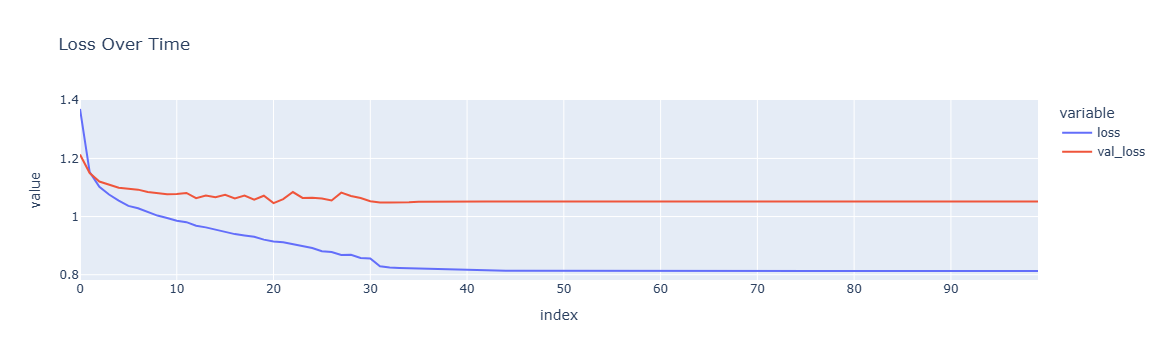

In [21]:
fig = px.line(
    history.history,
    y=['loss', 'val_loss'],
    labels={'x': 'Epoch', 'y': 'Loss'},
    title='Loss Over Time'
)
fig.show()

In [22]:
model.evaluate(X_test, y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5803 - loss: 1.0199


[1.0198613405227661, 0.5802721381187439]

In [23]:
y.value_counts()

quality
3    2198
2    1457
4     880
5     175
1     163
0      20
6       5
Name: count, dtype: int64

### Re-structure the task:

Let's try quantile splitting the outputs into two categories: high quality wines and low quality wines.

In [24]:
df['quality'].value_counts()

quality
3    2198
2    1457
4     880
5     175
1     163
0      20
6       5
Name: count, dtype: int64

In [25]:
pd.qcut(df['quality'], q=2, labels=[0,1]).value_counts()

quality
0    3838
1    1060
Name: count, dtype: int64

In [26]:
y = pd.qcut(df['quality'], q=2, labels=[0,1]).astype('float').copy()
X = df.drop('quality', axis=1).copy()

In [27]:
y.value_counts()

quality
0.0    3838
1.0    1060
Name: count, dtype: int64

In [28]:
scalar = StandardScaler()

X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=34)

In [30]:
num_classes = 1

In [33]:
inputs = tf.keras.Input(shape=(num_features, ))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(num_classes, activation='sigmoid')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

batch_size = 32
epochs = 100

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[tf.keras.callbacks.ReduceLROnPlateau()]
)

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7954 - loss: 0.4556 - val_accuracy: 0.7653 - val_loss: 0.4524 - learning_rate: 0.0010
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8260 - loss: 0.3864 - val_accuracy: 0.7784 - val_loss: 0.4334 - learning_rate: 0.0010
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8286 - loss: 0.3713 - val_accuracy: 0.7813 - val_loss: 0.4227 - learning_rate: 0.0010
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8326 - loss: 0.3597 - val_accuracy: 0.7755 - val_loss: 0.4398 - learning_rate: 0.0010
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8381 - loss: 0.3528 - val_accuracy: 0.7843 - val_loss: 0.4180 - learning_rate: 0.0010
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8363 - loss: 0.3468 - val_accuracy: 0.7741 - val_loss: 0.4115 - learning_rate: 0.0010
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8370 - loss: 0.3398 - val_acc

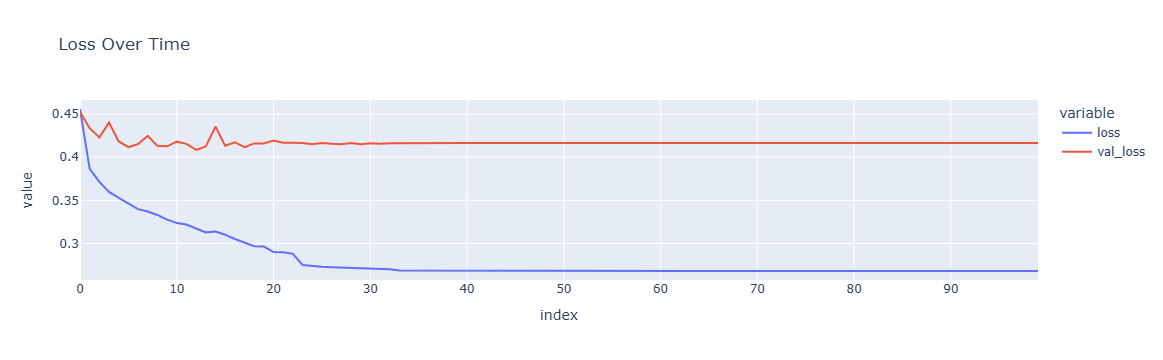

In [34]:
fig = px.line(
    history.history,
    y=['loss', 'val_loss'],
    labels={'x': 'Epoch', 'y': 'Loss'},
    title='Loss Over Time'
)
fig.show()

In [35]:
model.evaluate(X_test, y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8374 - loss: 0.3670


[0.3670119047164917, 0.8374149799346924]